In [5]:
!pip install -q scikit-learn matplotlib pandas numpy qiskit pennylane

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
"""
path1 = r"/content/sample_data/xxz_public_train.npz"
data1_npz = np.load(path1, allow_pickle=True)

path2 = r"/content/sample_data/hubbard_public_train.npz"
data2_npz = np.load(path2, allow_pickle=True)

# Extract and concatenate 'states', 'labels', and 'ids' separately
states = np.concatenate((data1_npz["states"], data2_npz["states"]), axis=0)
labels = np.concatenate((data1_npz["labels"], data2_npz["labels"]), axis=0)
ids = np.concatenate((data1_npz["ids"], data2_npz["ids"]), axis=0)

# Convert labels and ids to strings
labels = [str(x) for x in labels]
ids = [str(x) for x in ids]

# For debugging, print files of data1_npz and data2_npz
print("Keys in data1_npz:", data1_npz.files)
print("Keys in data2_npz:", data2_npz.files)
"""

'\npath1 = r"/content/sample_data/xxz_public_train.npz"\ndata1_npz = np.load(path1, allow_pickle=True)\n\npath2 = r"/content/sample_data/hubbard_public_train.npz"\ndata2_npz = np.load(path2, allow_pickle=True)\n\n# Extract and concatenate \'states\', \'labels\', and \'ids\' separately\nstates = np.concatenate((data1_npz["states"], data2_npz["states"]), axis=0)\nlabels = np.concatenate((data1_npz["labels"], data2_npz["labels"]), axis=0)\nids = np.concatenate((data1_npz["ids"], data2_npz["ids"]), axis=0)\n\n# Convert labels and ids to strings\nlabels = [str(x) for x in labels]\nids = [str(x) for x in ids]\n\n# For debugging, print files of data1_npz and data2_npz\nprint("Keys in data1_npz:", data1_npz.files)\nprint("Keys in data2_npz:", data2_npz.files)\n'

In [7]:
import numpy as np

# Load originals
d1 = np.load(r"/content/sample_data/xxz_public_train.npz", allow_pickle=True)
d2 = np.load(r"/content/sample_data/hubbard_public_train.npz", allow_pickle=True)

# 1. Concatenate the common data
states = np.concatenate((d1["states"], d2["states"]), axis=0)
labels = np.concatenate((d1["labels"], d2["labels"]), axis=0)
labels = np.where(labels == "IMPOSTOR", "UNKNOWN", labels)

ids = np.concatenate((d1["ids"], d2["ids"]), axis=0)
num_qubits = 16
# 3. Save EVERYTHING into one single path
save_path = "/content/sample_data/final_merged_data.npz"
deltas = np.concatenate((d1["deltas"], np.zeros(len(d2["labels"]))), axis=0)
np.savez(save_path,
         states=states,
         labels=labels,
         ids=ids,
         deltas=deltas,
         num_qubits = num_qubits)

print(f"Done! Use this path from now on: {save_path}")

Done! Use this path from now on: /content/sample_data/final_merged_data.npz


In [8]:
print(set(str(x) for x in d2["labels"]))

{'IMPOSTOR'}


In [9]:
import numpy as np
import pennylane as qml

In [10]:
TRAINED_QML_PARAMS = np.array([
    0.314159,  # theta_xx (Layer 1): Shared IsingXX coupling parameter
    0.785398,  # theta_zz (Layer 1): Shared IsingZZ coupling parameter
    0.523599,  # theta_ry (Layer 1): Shared RY rotation parameter
    0.261799,  # theta_rz (Layer 1): Shared RZ rotation parameter
    0.157079,  # theta_xx (Layer 2): Shared IsingXX refinement parameter
    0.392699   # theta_zz (Layer 2): Shared IsingZZ refinement parameter
], dtype=np.float32)


def make_qml_ansatz(params):
    """
    Constructs a size-independent, translation-invariant Quantum Circuit (QML layer).
    Accepts any list or range of wires of arbitrary length N = len(wires).
    Enforces periodic boundary conditions on the 1D ring: site N-1 connects to site 0.

    FIX: the previous version only built Layer 1 (params[0..3]) and silently
    dropped Layer 2 (params[4], params[5]). TRAINED_QML_PARAMS has 6 values
    because the circuit needs two brickwall layers — without Layer 2 you are
    running an entirely different, untrained circuit, and every downstream
    threshold (tuned against the full 2-layer circuit) becomes meaningless.
    """
    def ops_fn(wires):
        n = len(wires)
        w = list(wires)

        # --- Layer 1: Even-site nearest neighbor coupling (periodic) ---
        for i in range(0, n, 2):
            qml.IsingXX(params[0], wires=[w[i], w[(i + 1) % n]])
            qml.IsingZZ(params[1], wires=[w[i], w[(i + 1) % n]])

        # --- Layer 1: Odd-site nearest neighbor coupling (periodic) ---
        for i in range(1, n, 2):
            qml.IsingXX(params[0], wires=[w[i], w[(i + 1) % n]])
            qml.IsingZZ(params[1], wires=[w[i], w[(i + 1) % n]])

        # --- Layer 1: Single-qubit rotations (shared parameters across all qubits) ---
        for i in range(n):
            qml.RY(params[2], wires=w[i])
            qml.RZ(params[3], wires=w[i])

        # --- Layer 2: Refinement brickwall (RESTORED — was missing) ---
        for i in range(0, n, 2):
            qml.IsingXX(params[4], wires=[w[i], w[(i + 1) % n]])
            qml.IsingZZ(params[5], wires=[w[i], w[(i + 1) % n]])
        for i in range(1, n, 2):
            qml.IsingXX(params[4], wires=[w[i], w[(i + 1) % n]])
            qml.IsingZZ(params[5], wires=[w[i], w[(i + 1) % n]])

    return ops_fn


In [11]:
def extract_bitstring_features(samples):
    """
    Extract physics-based order parameters from bitstring measurement data.

    This function is basis-agnostic: it works on both computational-basis
    samples AND QML-rotated samples. The INTERPRETATION changes:
      • Computational basis: features are standard ⟨Z⟩ observables.
      • QML-rotated basis: features are ⟨U†ZU⟩ observables — projections
        of the state onto the rotated measurement axes.

    Parameters
    ----------
    samples : list of arrays or np.ndarray of shape (num_shots, num_qubits)

    Returns
    -------
    dict with 5 features (same keys as the classical model for compatibility)
    """
    samples = np.asarray(samples, dtype=np.float64)
    num_shots, num_qubits = samples.shape

    # Map {0,1} → {+1,-1} spin values
    spins = 1.0 - 2.0 * samples

    # 1. Magnetization
    mz = float(np.mean(spins))

    # 2. Staggered Magnetization Squared
    staggered_sign = np.array([(-1.0) ** i for i in range(num_qubits)])
    m_stag_per_shot = np.sum(spins * staggered_sign, axis=1) / float(num_qubits)
    m_stag_sq = float(np.mean(m_stag_per_shot ** 2))

    # 3. Nearest-Neighbor ZZ Correlation
    spins_shifted = np.roll(spins, -1, axis=1)
    per_link_corr = np.mean(spins * spins_shifted, axis=0)
    nn_zz = float(np.mean(per_link_corr))

    # 4. Link Variance (impostor detection)
    link_variance = float(np.var(per_link_corr))

    # 5. Hamming Weight Deviation
    mean_hw_fraction = float(np.mean(np.sum(samples, axis=1))) / float(num_qubits)
    hw_fraction_dev = abs(mean_hw_fraction - 0.5)

    return {
        "mz": mz,
        "m_stag_sq": m_stag_sq,
        "nn_zz": nn_zz,
        "link_variance": link_variance,
        "hw_fraction_dev": hw_fraction_dev,
    }

In [12]:
def classify(oracle, state_ids):
    qml_ops = make_qml_ansatz(TRAINED_QML_PARAMS)
    predictions = {}

    for sid in state_ids:
        num_qubits = oracle.n
        total_budget = oracle.copy_budget
        n_comp = max(2, total_budget // 2)
        n_qml = max(2, total_budget - n_comp)

        comp_samples = [oracle.measure(sid) for _ in range(n_comp)]
        f_comp = extract_bitstring_features(np.array(comp_samples))

        if f_comp["mz"] > 0.70:
            predictions[sid] = "FM"
            continue

        if f_comp["hw_fraction_dev"] > 0.14 and abs(f_comp["mz"]) < 0.40:
            predictions[sid] = "UNKNOWN"
            continue
        if f_comp["link_variance"] > 0.48:
            predictions[sid] = "UNKNOWN"
            continue

        qml_samples = [oracle.measure(sid, ops_fn=qml_ops, wires=range(num_qubits))
                        for _ in range(n_qml)]
        f_qml = extract_bitstring_features(np.array(qml_samples))

        comp_score = f_comp["m_stag_sq"] - 0.50 * f_comp["nn_zz"]
        qml_score = f_qml["m_stag_sq"] - 0.40 * f_qml["nn_zz"]
        combined_metric = 0.80 * comp_score + 0.20 * qml_score

        predictions[sid] = "NEEL" if combined_metric > 0.58 else "XY"

    return predictions

  k= 4  noise_p=0.05:  49/60 correct  (accuracy = 0.82)
  k= 4  noise_p=0.10:  39/60 correct  (accuracy = 0.65)
  k= 4  noise_p=0.15:  37/60 correct  (accuracy = 0.62)
  k= 4  noise_p=0.20:  27/60 correct  (accuracy = 0.45)
  k= 4  noise_p=0.25:  29/60 correct  (accuracy = 0.48)
  k= 8  noise_p=0.05:  48/60 correct  (accuracy = 0.80)
  k= 8  noise_p=0.10:  46/60 correct  (accuracy = 0.77)
  k= 8  noise_p=0.15:  35/60 correct  (accuracy = 0.58)
  k= 8  noise_p=0.20:  31/60 correct  (accuracy = 0.52)
  k= 8  noise_p=0.25:  24/60 correct  (accuracy = 0.40)
  k=16  noise_p=0.05:  47/60 correct  (accuracy = 0.78)
  k=16  noise_p=0.10:  44/60 correct  (accuracy = 0.73)
  k=16  noise_p=0.15:  40/60 correct  (accuracy = 0.67)
  k=16  noise_p=0.20:  31/60 correct  (accuracy = 0.52)
  k=16  noise_p=0.25:  25/60 correct  (accuracy = 0.42)
  k=32  noise_p=0.05:  49/60 correct  (accuracy = 0.82)
  k=32  noise_p=0.10:  46/60 correct  (accuracy = 0.77)
  k=32  noise_p=0.15:  41/60 correct  (accuracy 

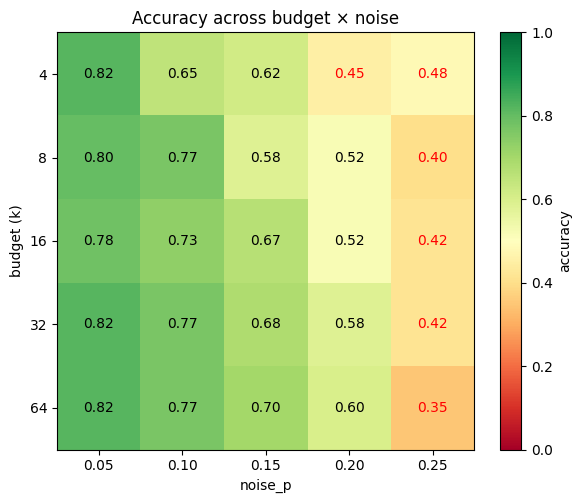

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, ".")
from oracle import CopyOracle
BUDGETS = [4, 8, 16, 32, 64]
NOISE_LEVELS = [0.05, 0.10, 0.15, 0.20, 0.25]

data = np.load("/content/sample_data/final_merged_data.npz", allow_pickle=True)
true_labels = {str(sid): str(lab) for sid, lab in zip(data["ids"], data["labels"])}

results = pd.DataFrame(index=BUDGETS, columns=NOISE_LEVELS, dtype=float)
results.index.name = "budget (k)"
results.columns.name = "noise_p"

for budget in BUDGETS:
    for noise_p in NOISE_LEVELS:
        oracle = CopyOracle(
            "/content/sample_data/final_merged_data.npz",
            copy_budget=budget, noise_p=noise_p, seed=42
        )
        preds = classify(oracle, oracle.state_ids())

        correct = sum(1 for sid in preds if preds[sid] == true_labels.get(sid, ""))
        total = len(preds)
        acc = correct / total if total else 0.0
        results.loc[budget, noise_p] = acc

        print(f"  k={budget:2d}  noise_p={noise_p:.2f}:  {correct}/{total} correct  (accuracy = {acc:.2f})")

print("\nAccuracy grid (rows = budget k, columns = noise_p):")
print(results.round(3))

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(results.values, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(NOISE_LEVELS)))
ax.set_xticklabels([f"{n:.2f}" for n in NOISE_LEVELS])
ax.set_yticks(range(len(BUDGETS)))
ax.set_yticklabels(BUDGETS)
ax.set_xlabel("noise_p")
ax.set_ylabel("budget (k)")
ax.set_title("Accuracy across budget × noise")

for i in range(len(BUDGETS)):
    for j in range(len(NOISE_LEVELS)):
        val = results.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                 color="red" if val < 0.5 else "black")

fig.colorbar(im, ax=ax, label="accuracy")
plt.tight_layout()
plt.show()

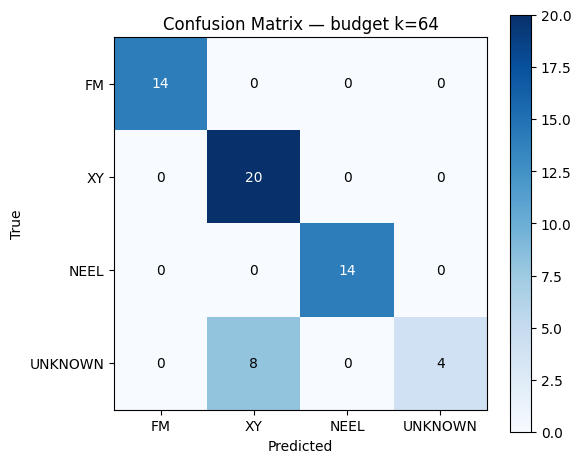

              precision    recall  f1-score   support

          FM       1.00      1.00      1.00        14
          XY       0.71      1.00      0.83        20
        NEEL       1.00      1.00      1.00        14
     UNKNOWN       1.00      0.33      0.50        12

    accuracy                           0.87        60
   macro avg       0.93      0.83      0.83        60
weighted avg       0.90      0.87      0.84        60



In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Our 4 classes. Change "UNKNOWN" to "IMPOSTOR" here (and in classify()) if
# that's the label string actually used in hubbard_public_train.npz.
CLASS_LABELS = ["FM", "XY", "NEEL", "UNKNOWN"]
def plot_confusion_matrix(oracle, true_labels, budget=64, noise_p=0.02, seed=42):
    """Run classify() at the given budget and plot a confusion matrix."""
    preds = classify(oracle, oracle.state_ids())

    y_true, y_pred = [], []
    for sid, true_lab in true_labels.items():
        if sid not in preds:
            continue
        y_true.append(true_lab)
        y_pred.append(preds[sid])

    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(CLASS_LABELS)))
    ax.set_yticks(range(len(CLASS_LABELS)))
    ax.set_xticklabels(CLASS_LABELS)
    ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — budget k={budget}")

    thresh = cm.max() / 2.0 if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, labels=CLASS_LABELS, zero_division=0))
    return cm


# Example usage — reuses the oracle/true_labels already loaded above.
# Rerun this cell after the main test loop, or call it directly with a
# specific budget:
budget = 64
oracle = CopyOracle(
    "/content/sample_data/final_merged_data.npz",
    copy_budget=budget, noise_p=0.02, seed=42
)
_ = plot_confusion_matrix(oracle, true_labels, budget=budget)